In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
import pickle

In [3]:
df=pd.read_csv("tmdb_5000_movies.csv")

In [4]:
df1=pd.read_csv("tmdb_5000_credits.csv")

In [5]:
df1

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...
4798,9367,El Mariachi,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,72766,Newlyweds,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,231617,"Signed, Sealed, Delivered","[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,126186,Shanghai Calling,"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


In [6]:
df = df.merge(df1, on = "title")

In [7]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'movie_id', 'cast', 'crew'],
      dtype='object')

In [8]:
df.original_language

0       en
1       en
2       en
3       en
4       en
        ..
4804    es
4805    en
4806    en
4807    en
4808    en
Name: original_language, Length: 4809, dtype: object

Columns to be removed

homepage
original_title

production_compaines
production_countries
spoken_languages
status
tagline

In [9]:
df.drop(columns = ["homepage","original_title","production_companies","production_countries","spoken_languages","status","tagline"],inplace = True)

In [10]:
df.shape,

((4809, 16),)

<Axes: ylabel='original_language'>

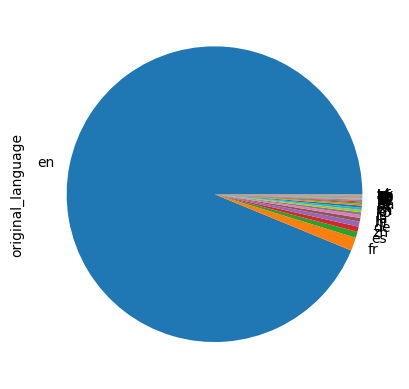

In [11]:
df.original_language.value_counts().plot(kind = "pie")

In [12]:
df['overview_original']=df['overview']

As the dataset contains more english movies. We will remove movies of other languages 

In [13]:
df[df.original_language == "hi"]

,budget,genres,id,keywords,original_language,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,movie_id,cast,crew,overview_original
1026,0,"[{""id"": 18, ""name"": ""Drama""}]",7504,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",hi,It's 1947 and the borderlines between India an...,1.246883,1998-09-16,528972,101.0,Earth,6.6,9,7504,"[{""cast_id"": 2, ""character"": ""Dil Navaz"", ""cre...","[{""credit_id"": ""52fe4480c3a36847f8099e81"", ""de...",It's 1947 and the borderlines between India an...
2967,7400000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",14395,"[{""id"": 596, ""name"": ""adultery""}, {""id"": 34094...",hi,Dev and Maya are both married to different peo...,3.246903,2006-08-11,17000000,193.0,Kabhi Alvida Naa Kehna,6.1,42,14395,"[{""cast_id"": 1, ""character"": ""Dev Saran"", ""cre...","[{""credit_id"": ""58a5e57892514152a70006bf"", ""de...",Dev and Maya are both married to different peo...
2976,0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 35, ""name...",58051,[],hi,Believing himself to be a jinx and bringing ba...,0.120820,2010-04-30,0,135.0,Housefull,5.2,29,58051,"[{""cast_id"": 1, ""character"": ""Aarush"", ""credit...","[{""credit_id"": ""52fe4952c3a36847f81943a9"", ""de...",Believing himself to be a jinx and bringing ba...
3094,0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 878, ""na...",32740,[],hi,Krishna (Roshan) is born with magical powers -...,3.759988,2006-06-23,0,154.0,Krrish,5.5,46,32740,"[{""cast_id"": 1, ""character"": ""Krishna Mehra / ...","[{""credit_id"": ""57f69c2dc3a36810580001bc"", ""de...",Krishna (Roshan) is born with magical powers -...
3162,0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",132316,"[{""id"": 10540, ""name"": ""bollywood""}, {""id"": 15...",hi,"An ex-army man, leading a double life in Londo...",5.900535,2012-11-13,0,176.0,Jab Tak Hai Jaan,7.3,66,132316,"[{""cast_id"": 1, ""character"": ""Major Samar Anan...","[{""credit_id"": ""52fe4b8fc3a368484e18f009"", ""de...","An ex-army man, leading a double life in Londo..."
3233,7700000,"[{""id"": 10749, ""name"": ""Romance""}]",185008,[],hi,Yeh Jawaani Hai Deewani features two polar opp...,3.353176,2013-05-31,46000000,159.0,Yeh Jawaani Hai Deewani,7.2,79,185008,"[{""cast_id"": 1, ""character"": ""Bunny"", ""credit_...","[{""credit_id"": ""52fe4cd39251416c75126bd7"", ""de...",Yeh Jawaani Hai Deewani features two polar opp...
3332,0,"[{""id"": 10751, ""name"": ""Family""}, {""id"": 35, ""...",14165,"[{""id"": 242, ""name"": ""new york""}, {""id"": 5626,...",hi,"A poor New York resident, who is of Indian ori...",0.553752,2007-04-27,0,156.0,Ta Ra Rum Pum,6.0,13,14165,"[{""cast_id"": 3, ""character"": ""Rajveer 'RV' Sin...","[{""credit_id"": ""52fe45d39251416c75063b65"", ""de...","A poor New York resident, who is of Indian ori..."
3379,7000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",4251,"[{""id"": 2038, ""name"": ""love of one's life""}, {...",hi,The story of the love between Veer Pratap Sing...,3.721858,2004-11-12,29385320,192.0,Veer-Zaara,7.4,64,4251,"[{""cast_id"": 11, ""character"": ""Veer Pratap Sin...","[{""credit_id"": ""52fe43b6c3a36847f8069a81"", ""de...",The story of the love between Veer Pratap Sing...
3548,2200000,"[{""id"": 18, ""name"": ""Drama""}]",7913,"[{""id"": 2387, ""name"": ""new delhi india""}, {""id...",hi,"A young idealistic English filmmaker, Sue, arr...",5.206967,2006-01-26,11502151,157.0,Rang De Basanti,7.2,97,7913,"[{""cast_id"": 2, ""character"": ""DJ"", ""credit_id""...","[{""credit_id"": ""52fe4489c3a36847f809b7f5"", ""de...","A young idealistic English filmmaker, Sue, arr..."
3558,0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 28, ""name...",63006,"[{""id"": 7090, ""name"": ""goa""}, {""id"": 33067, ""n...",hi,"We hurtle into the bylanes, beach shacks and r...",0.075817,2011-04-22,0,130.0,Dum Maaro Dum,5.4,7,63006,"[{""cast_id"": 1, ""character"": ""ACP Vishnu Kamat...","[{""credit_id"": ""594c6f2c9251413127019d7

In [14]:
#df.drop(columns = "original_language" , inplace =True)

### DATA PROCESSING

In [15]:
import ast

In [16]:
def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name']) 
    return L 

In [17]:
df.dropna(inplace=True)

In [18]:
df.genres = df.genres.apply(convert)

C:\Users\subar\AppData\Local\Temp\ipykernel_29356\1393873971.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.budget)


<Axes: xlabel='budget', ylabel='Density'>

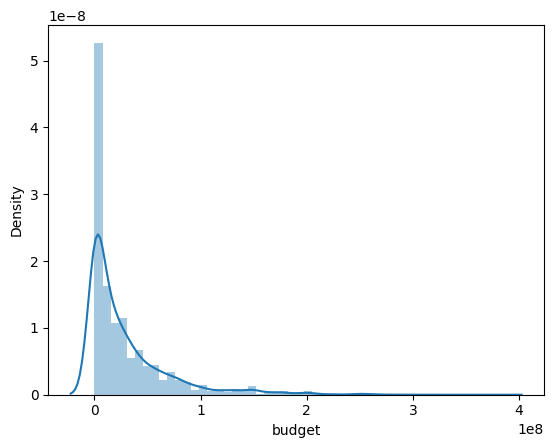

In [19]:
sns.distplot(df.budget)

In [20]:
df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language', 'overview',
       'popularity', 'release_date', 'revenue', 'runtime', 'title',
       'vote_average', 'vote_count', 'movie_id', 'cast', 'crew',
       'overview_original'],
      dtype='object')

In [21]:
df.keywords = df.keywords.apply(convert)

In [22]:
df["year"] = df.release_date.str.split("-",expand = True)[0]

In [23]:
df.drop(columns = 'release_date' , inplace =True)


In [24]:
df.revenue[df.revenue == 0 ] = df.revenue.mean()

C:\Users\subar\AppData\Local\Temp\ipykernel_29356\1953446866.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.revenue[df.revenue == 0 ] = df.revenue.mean()


In [25]:
df.budget[df.budget == 0 ] = df.budget.mean()

C:\Users\subar\AppData\Local\Temp\ipykernel_29356\4201540858.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.budget[df.budget == 0 ] = df.budget.mean()


In [26]:
df["performance"] = (df.revenue )/ (df.budget)

C:\Users\subar\AppData\Local\Temp\ipykernel_29356\2524345392.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.performance)


<Axes: xlabel='performance', ylabel='Density'>

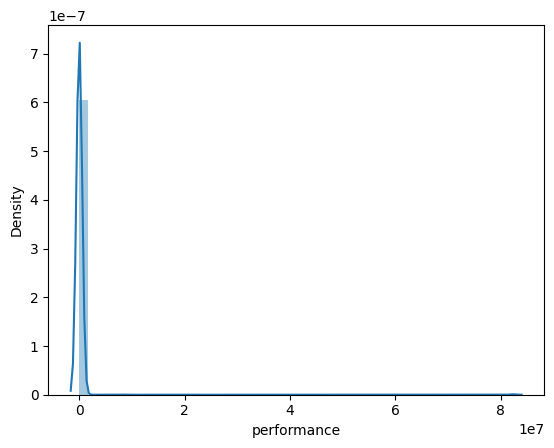

In [27]:
sns.distplot(df.performance)

In [28]:
df.performance[df.performance >50] =1

C:\Users\subar\AppData\Local\Temp\ipykernel_29356\3126386855.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.performance[df.performance >50] =1


In [29]:
df.head(1)

,budget,genres,id,keywords,original_language,overview,popularity,revenue,runtime,title,vote_average,vote_count,movie_id,cast,crew,overview_original,year,performance
0,237000000.0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,2.787965e+09,162.0,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...","In the 22nd century, a paraplegic Marine is di...",2009,11.763566


In [30]:
df.performance

0       11.763566
1        3.203333
2        3.594590
3        4.339756
4        1.092843
          ...    
4804     9.276909
4805     1.000000
4806     2.834679
4807     2.834679
4808     2.834679
Name: performance, Length: 4805, dtype: float64

C:\Users\subar\AppData\Local\Temp\ipykernel_29356\3730632947.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.runtime)


<Axes: xlabel='runtime', ylabel='Density'>

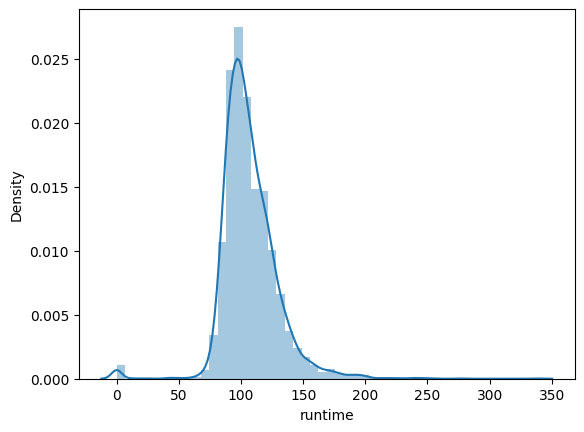

In [31]:
sns.distplot(df.runtime)

In [32]:
df.vote_average.isnull().sum()

0

In [33]:
df["vote_average"][0]

7.2

C:\Users\subar\AppData\Local\Temp\ipykernel_29356\2196465609.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.vote_average)


<Axes: xlabel='vote_average', ylabel='Density'>

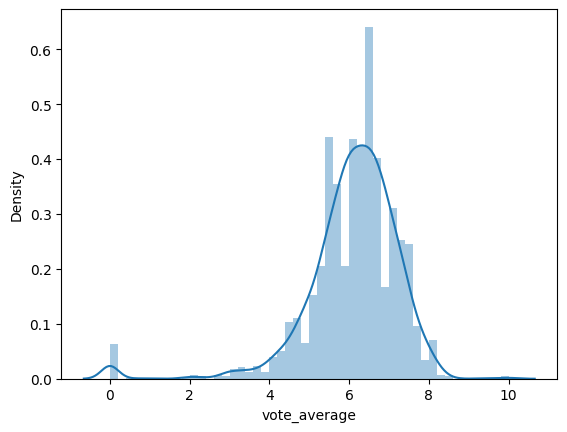

In [34]:
sns.distplot(df.vote_average)

In [35]:
df.cast= df.cast.apply(convert)

In [36]:
df.cast=df.cast.apply(lambda x : x[0:3])

In [37]:
df.crew[0]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [38]:
def director(text):
    L = []
    for i in ast.literal_eval(text):
       if i["job"] == "Director" :
        L.append(i['name'])
        
    return L 

In [39]:
df["director"] = df.crew.apply(director)

In [40]:
df.head(50)

,budget,genres,id,keywords,original_language,overview,popularity,revenue,runtime,title,vote_average,vote_count,movie_id,cast,crew,overview_original,year,performance,director
0,237000000.0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,2.787965e+09,162.0,Avatar,7.2,11800,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...","In the 22nd century, a paraplegic Marine is di...",2009,11.763566,[James Cameron]
1,300000000.0,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...",en,"Captain Barbossa, long believed to be dead, ha...",139.082615,9.610000e+08,169.0,Pirates of the Caribbean: At World's End,6.9,4500,285,"[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...","Captain Barbossa, long believed to be dead, ha...",2007,3.203333,[Gore Verbinski]
2,245000000.0,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",en,A cryptic message from Bond’s past sends him o...,107.376788,8.806746e+08,148.0,Spectre,6.3,4466,206647,"[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",A cryptic message from Bond’s past sends him o...,2015,3.594590,[Sam Mendes]
3,250000000.0,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",en,Following the death of District Attorney Harve...,112.312950,1.084939e+09,165.0,The Dark Knight Rises,7.6,9106,49026,"[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",Following the death of District Attorney Harve...,2012,4.339756,[Christopher Nolan]
4,260000000.0,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...",en,"John Carter is a war-weary, former military ca...",43.926995,2.841391e+08,132.0,John Carter,6.1,2124,49529,"[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...","John Carter is a war-weary, former military ca...",2012,1.092843,[Andrew Stanton]
5,258000000.0,"[Fantasy, Action, Adventure]",559,"[dual identity, amnesia, sandstorm, love of on...",en,The seemingly invincible Spider-Man goes up ag...,115.699814,8.908716e+08,139.0,Spider-Man 3,5.9,3576,559,"[Tobey Maguire, Kirsten Dunst, James Franco]","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de...",The seemingly invincible Spider-Man goes up ag...,2007,3.452991,[Sam Raimi]
6,260000000.0,"[Animation, Family]",38757,"[hostage, magic, horse, fairy tale, musical, p...",en,When the kingdom's most wanted-and most charmi...,48.681969,5.917949e+08,100.0,Tangled,7.4,3330,38757,"[Zachary Levi, Mandy Moore, Donna Murphy]","[{""credit_id"": ""52fe46db9251416c91062101"", ""de...",When the kingdom's most wanted-and most charmi...,2010,2.276134,"[Byron Howard, Nathan Greno]"
7,280000000.0,"[Action, Adventure, Science Fiction]",99861,"[marvel comic, sequel, superhero, based on com...",en,When Tony Stark tries to jumpstart a dormant p...,134.279229,1.405404e+09,141.0,Avengers: Age of Ultron,7.3,6767,99861,"[Robert Downey Jr., Chris Hemsworth, Mark Ruff...","[{""credit_id"": ""55d5f7d4c3a3683e7e0016eb"", ""de...",When Tony Stark tries to jumpstart a dormant p...,2015,5.019299,[Joss Whedon]
8,250000000.0,"[Adventure, Fantasy, Family]",767,"[witch, magic, broom, school of witchcraft, wi...",en,"As Harry begins his sixth year at Hogwarts, he...",98.885637,9.339592e+08,153.0,Harry Potter and the Half-Blood Prince,7.4,5293,767,"[Daniel Radcliffe, Rupert Grint, Emma Watson]","[{""credit_id"": ""52fe4273c3a36847f801fab1"", ""de...","As Harry begins his sixth year at Hogwarts, he...",2009,3.735837,[David Yates]
9,250000000.0,"[Action, Adventure, Fantasy]",209112,"[dc comics, vigilante, superhero, based on com...",en,Fearing the actions of a god-

In [41]:
df.drop(columns = "crew" , inplace =True)

In [42]:
df.sort_values(by='performance', ascending=False).head(50)


,budget,genres,id,keywords,original_language,overview,popularity,revenue,runtime,title,vote_average,vote_count,movie_id,cast,overview_original,year,performance,director
3891,2500000.0,"[Adventure, Action, Thriller]",658,"[secret organization, secret intelligence serv...",en,Special agent 007 (Sean Connery) comes face to...,47.812466,1.248811e+08,110.0,Goldfinger,7.2,987,658,"[Sean Connery, Honor Blackman, Gert Fröbe]",Special agent 007 (Sean Connery) comes face to...,1964,49.952425,[Guy Hamilton]
4201,1700000.0,"[Drama, Thriller]",1999,"[age difference, fishing, arbitrary law, condu...",en,"Summertime on the coast of Maine, ""In the Bedr...",6.979638,8.234360e+07,130.0,In the Bedroom,6.4,89,1999,"[Tom Wilkinson, Sissy Spacek, Nick Stahl]","Summertime on the coast of Maine, ""In the Bedr...",2001,48.437414,[Todd Field]
4637,250000.0,"[Comedy, Drama, Romance]",2255,"[new jersey, coming out, love of one's life, b...",en,Holden and Banky are comic book artists. Every...,20.601483,1.202127e+07,113.0,Chasing Amy,6.7,433,2255,"[Ben Affleck, Joey Lauren Adams, Jason Lee]",Holden and Banky are comic book artists. Every...,1997,48.085088,[Kevin Smith]
4356,1000000.0,[Documentary],1781,"[climate change, greenhouse effect, climate, e...",en,A documentary on Al Gore's campaign to make th...,14.139004,4.624300e+07,100.0,An Inconvenient Truth,6.7,251,1781,"[Al Gore, Billy West, Ronald Reagan]",A documentary on Al Gore's campaign to make th...,2006,46.243000,[Davis Guggenheim]
4004,2600000.0,"[Western, Comedy]",11072,"[gun, saloon, governor, marching band, comedy,...",en,A town – where everyone seems to be named John...,22.793929,1.195000e+08,93.0,Blazing Saddles,7.2,609,11072,"[Cleavon Little, Gene Wilder, Harvey Korman]",A town – where everyone seems to be named John...,1974,45.961538,[Mel Brooks]
4195,1800000.0,"[Comedy, Romance]",98557,[],en,A group of college friends are reunited after ...,0.215440,8.234360e+07,101.0,Dysfunctional Friends,5.0,4,98557,"[Stacey Dash, Reagan Gomez-Preston, Wesley Jon...",A group of college friends are reunited after ...,2012,45.746446,[Corey Grant]
4194,1800000.0,"[Action, Science Fiction]",205126,"[ufo, extraterrestrial, spaceship, alien]",en,When Earth is attacked by a hostile alien forc...,1.959405,8.234360e+07,86.0,Independence Daysaster,4.2,22,205126,"[Casey Dubois, Iain Belcher, Andrea Brooks]",When Earth is attacked by a hostile alien forc...,2013,45.746446,[W.D. Hogan]
4181,1800000.0,"[Drama, Romance]",542,"[heart attack, drug traffic, drug crime, mexic...",es,The young Father Amaro is put to the test. He ...,2.179428,8.234360e+07,118.0,The Crime of Padre Amaro,6.2,36,542,"[Gael García Bernal, Ana Claudia Talancón, San...",The young Father Amaro is put to the test. He ...,2002,45.746446,[Carlos Carrera]
4176,1900000.0,[Drama],295886,[],en,West Philadelphia basketball star Sergio Taylo...,1.367751,8.234360e+07,89.0,Brotherly Love,6.9,21,295886,"[Keke Palmer, Cory Hardrict, Eric D. Hill Jr.]",West Philadelphia basketball star Sergio Taylo...,2015,43.338739,[Jamal Hill]
3703,6000000.0,"[Comedy, Drama, Romance]",712,"[upper class, love at first sight, wedding vow...",en,Four Weddings And A Funeral is a British comed...,29.834065,2.547008e+08,117.0,Four Weddings and a Funeral,6.6,632,712,"[Hugh Grant, Andie MacDowell, James Fleet]",Four Weddings And A Funeral is a British comed...,1994,42.450139,[Mike Newell]


In [43]:

 df['overview'] = df['overview'].apply(lambda x:x.split())


In [44]:
df.overview

0       [In, the, 22nd, century,, a, paraplegic, Marin...
1       [Captain, Barbossa,, long, believed, to, be, d...
2       [A, cryptic, message, from, Bond’s, past, send...
3       [Following, the, death, of, District, Attorney...
4       [John, Carter, is, a, war-weary,, former, mili...
                              ...                        
4804    [El, Mariachi, just, wants, to, play, his, gui...
4805    [A, newlywed, couple's, honeymoon, is, upended...
4806    ["Signed,, Sealed,, Delivered", introduces, a,...
4807    [When, ambitious, New, York, attorney, Sam, is...
4808    [Ever, since, the, second, grade, when, he, fi...
Name: overview, Length: 4805, dtype: object

In [45]:
def collapse(L):
    L1 = []
    for i in L:
        L1.append(i.replace(" ",""))
    return L1

In [46]:
df['cast'] = df['cast'].apply(collapse)
df['director'] = df['director'].apply(collapse)
df['genres'] = df['genres'].apply(collapse)
df['keywords'] = df['keywords'].apply(collapse)

In [47]:
df["tags"] = df.genres + df.keywords+ df.cast+df.director+df.overview

In [48]:
df.tags[0]

['Action',
 'Adventure',
 'Fantasy',
 'ScienceFiction',
 'cultureclash',
 'future',
 'spacewar',
 'spacecolony',
 'society',
 'spacetravel',
 'futuristic',
 'romance',
 'space',
 'alien',
 'tribe',
 'alienplanet',
 'cgi',
 'marine',
 'soldier',
 'battle',
 'loveaffair',
 'antiwar',
 'powerrelations',
 'mindandsoul',
 '3d',
 'SamWorthington',
 'ZoeSaldana',
 'SigourneyWeaver',
 'JamesCameron',
 'In',
 'the',
 '22nd',
 'century,',
 'a',
 'paraplegic',
 'Marine',
 'is',
 'dispatched',
 'to',
 'the',
 'moon',
 'Pandora',
 'on',
 'a',
 'unique',
 'mission,',
 'but',
 'becomes',
 'torn',
 'between',
 'following',
 'orders',
 'and',
 'protecting',
 'an',
 'alien',
 'civilization.']

In [49]:


df['tags'] = df['tags'].apply(lambda x: " ".join(x))
df.head()



,budget,genres,id,keywords,original_language,overview,popularity,revenue,runtime,title,vote_average,vote_count,movie_id,cast,overview_original,year,performance,director,tags
0,237000000.0,"[Action, Adventure, Fantasy, ScienceFiction]",19995,"[cultureclash, future, spacewar, spacecolony, ...",en,"[In, the, 22nd, century,, a, paraplegic, Marin...",150.437577,2.787965e+09,162.0,Avatar,7.2,11800,19995,"[SamWorthington, ZoeSaldana, SigourneyWeaver]","In the 22nd century, a paraplegic Marine is di...",2009,11.763566,[JamesCameron],Action Adventure Fantasy ScienceFiction cultur...
1,300000000.0,"[Adventure, Fantasy, Action]",285,"[ocean, drugabuse, exoticisland, eastindiatrad...",en,"[Captain, Barbossa,, long, believed, to, be, d...",139.082615,9.610000e+08,169.0,Pirates of the Caribbean: At World's End,6.9,4500,285,"[JohnnyDepp, OrlandoBloom, KeiraKnightley]","Captain Barbossa, long believed to be dead, ha...",2007,3.203333,[GoreVerbinski],Adventure Fantasy Action ocean drugabuse exoti...
2,245000000.0,"[Action, Adventure, Crime]",206647,"[spy, basedonnovel, secretagent, sequel, mi6, ...",en,"[A, cryptic, message, from, Bond’s, past, send...",107.376788,8.806746e+08,148.0,Spectre,6.3,4466,206647,"[DanielCraig, ChristophWaltz, LéaSeydoux]",A cryptic message from Bond’s past sends him o...,2015,3.594590,[SamMendes],Action Adventure Crime spy basedonnovel secret...
3,250000000.0,"[Action, Crime, Drama, Thriller]",49026,"[dccomics, crimefighter, terrorist, secretiden...",en,"[Following, the, death, of, District, Attorney...",112.312950,1.084939e+09,165.0,The Dark Knight Rises,7.6,9106,49026,"[ChristianBale, MichaelCaine, GaryOldman]",Following the death of District Attorney Harve...,2012,4.339756,[ChristopherNolan],Action Crime Drama Thriller dccomics crimefigh...
4,260000000.0,"[Action, Adventure, ScienceFiction]",49529,"[basedonnovel, mars, medallion, spacetravel, p...",en,"[John, Carter, is, a, war-weary,, former, mili...",43.926995,2.841391e+08,132.0,John Carter,6.1,2124,49529,"[TaylorKitsch, LynnCollins, SamanthaMorton]","John Carter is a war-weary, former military ca...",2012,1.092843,[AndrewStanton],Action Adventure ScienceFiction basedonnovel m...


In [50]:
df.tags[1]

"Adventure Fantasy Action ocean drugabuse exoticisland eastindiatradingcompany loveofone'slife traitor shipwreck strongwoman ship alliance calypso afterlife fighter pirate swashbuckler aftercreditsstinger JohnnyDepp OrlandoBloom KeiraKnightley GoreVerbinski Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems."

In [51]:
import nltk
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [52]:
def stem(text):
    y = []
    
    for i in text.split():
        y.append(ps.stem(i))
        
    return " ".join(y)

In [53]:
df.tags = df.tags.apply(stem)

In [54]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')
    

In [55]:


vector = cv.fit_transform(df['tags']).toarray()



In [56]:


vector



array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [57]:
from sklearn.metrics.pairwise import cosine_similarity

In [58]:
similarity = cosine_similarity(vector)

In [59]:


similarity



array([[1.        , 0.08346223, 0.0860309 , ..., 0.04499213, 0.        ,
        0.        ],
       [0.08346223, 1.        , 0.06063391, ..., 0.02378257, 0.        ,
        0.02646281],
       [0.0860309 , 0.06063391, 1.        , ..., 0.02451452, 0.        ,
        0.        ],
       ...,
       [0.04499213, 0.02378257, 0.02451452, ..., 1.        , 0.04134491,
        0.04279605],
       [0.        , 0.        , 0.        , ..., 0.04134491, 1.        ,
        0.09200874],
       [0.        , 0.02646281, 0.        , ..., 0.04279605, 0.09200874,
        1.        ]])

In [60]:


def search(movie):
    index = df[df['title'] == movie].index[0]
    
   
    distances = sorted(list(enumerate(similarity[index])),reverse=True,key = lambda x: x[1])
    for i in distances[1:6]:
        print(df.iloc[i[0]].title)
    



In [61]:
search("The Lion King")

Quest for Camelot
Nicholas Nickleby
Lonesome Jim
DysFunktional Family
The Prisoner of Zenda


In [62]:
df.cast


0        [SamWorthington, ZoeSaldana, SigourneyWeaver]
1           [JohnnyDepp, OrlandoBloom, KeiraKnightley]
2            [DanielCraig, ChristophWaltz, LéaSeydoux]
3            [ChristianBale, MichaelCaine, GaryOldman]
4          [TaylorKitsch, LynnCollins, SamanthaMorton]
                             ...                      
4804    [CarlosGallardo, JaimedeHoyos, PeterMarquardt]
4805         [EdwardBurns, KerryBishé, MarshaDietlein]
4806           [EricMabius, KristinBooth, CrystalLowe]
4807            [DanielHenney, ElizaCoupe, BillPaxton]
4808    [DrewBarrymore, BrianHerzlinger, CoreyFeldman]
Name: cast, Length: 4805, dtype: object

In [63]:
df.title

0                                         Avatar
1       Pirates of the Caribbean: At World's End
2                                        Spectre
3                          The Dark Knight Rises
4                                    John Carter
                          ...                   
4804                                 El Mariachi
4805                                   Newlyweds
4806                   Signed, Sealed, Delivered
4807                            Shanghai Calling
4808                           My Date with Drew
Name: title, Length: 4805, dtype: object

In [64]:


search('Pride & Prejudice')




Sense and Sensibility
Vamps
1982
Southpaw
Fiddler on the Roof


In [65]:
df.tags[0]

'action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav jamescameron in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization.'

In [66]:
df.year

0       2009
1       2007
2       2015
3       2012
4       2012
        ... 
4804    1992
4805    2011
4806    2013
4807    2012
4808    2005
Name: year, Length: 4805, dtype: object

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [68]:
def calculate_similarity(text1, text2):

    vectorizer = TfidfVectorizer()

    
    tfidf_matrix = vectorizer.fit_transform([text1, text2])

  
    similarity_score = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])

    return similarity_score[0][0]


text1 = "I like dogs"
text2 = "I love dogs"

similarity_mov = calculate_similarity(text1, text2)
print(f"Similarity score: {similarity_mov}")

Similarity score: 0.33609692727625756


# CAST SIMILARITY

In [69]:
df["cast_tags"] = df.cast.apply(lambda x: " ".join(x))

In [70]:
df.cast_tags

0        SamWorthington ZoeSaldana SigourneyWeaver
1           JohnnyDepp OrlandoBloom KeiraKnightley
2            DanielCraig ChristophWaltz LéaSeydoux
3            ChristianBale MichaelCaine GaryOldman
4          TaylorKitsch LynnCollins SamanthaMorton
                           ...                    
4804    CarlosGallardo JaimedeHoyos PeterMarquardt
4805         EdwardBurns KerryBishé MarshaDietlein
4806           EricMabius KristinBooth CrystalLowe
4807            DanielHenney ElizaCoupe BillPaxton
4808    DrewBarrymore BrianHerzlinger CoreyFeldman
Name: cast_tags, Length: 4805, dtype: object

In [71]:
vector1 = cv.fit_transform(df['cast_tags']).toarray()

In [72]:
similarity_cast = cosine_similarity(vector1)

In [73]:
def search_cast(movie):
    index = df[df['title'] == movie].index[0]
    
   
    distances = sorted(list(enumerate(similarity_cast[index])),reverse=True,key = lambda x: x[1])
    for i in distances[1:6]:
        print(df.iloc[i[0]].title)
        
    print(distances[:][1])

In [74]:
search_cast('Pride & Prejudice')

Pirates of the Caribbean: At World's End
Pirates of the Caribbean: Dead Man's Chest
Die Another Day
Surrogates
Doom
(1, 0.3333333333333334)


In [75]:
search_cast('Pride & Prejudice')

Pirates of the Caribbean: At World's End
Pirates of the Caribbean: Dead Man's Chest
Die Another Day
Surrogates
Doom
(1, 0.3333333333333334)


#  DIRECTOR

In [76]:
def abc(text):
    l=[]
    for i in text:
        try:
            l.append(i[0])
        except:
            l.append("NA")
    return l
    

In [77]:
df["director_tags"] = abc(df.director)

In [78]:
df.director_tags

0           JamesCameron
1          GoreVerbinski
2              SamMendes
3       ChristopherNolan
4          AndrewStanton
              ...       
4804     RobertRodriguez
4805         EdwardBurns
4806          ScottSmith
4807          DanielHsia
4808     BrianHerzlinger
Name: director_tags, Length: 4805, dtype: object

In [79]:
vector2 = cv.fit_transform(df['director_tags']).toarray()

In [80]:
similarity_director = cosine_similarity(vector2)

In [81]:
similarity_director


array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [82]:
def search_text(text):
    sim=[]
    y = []
    
    for i in text.split():
        y.append(ps.stem(i))
        
    text1 = " ".join(y)

    for i in df.index:
        
       
        similarity = calculate_similarity(text1, df.tags[i])
        sim.append(similarity)
        
    sim=sorted(list(enumerate(sim)),reverse=True,key = lambda x: x[1])
    
    for i in sim[0:4]:
        print(df.iloc[i[0]].title)
    
   

In [83]:
df.original_language

0       en
1       en
2       en
3       en
4       en
        ..
4804    es
4805    en
4806    en
4807    en
4808    en
Name: original_language, Length: 4805, dtype: object

In [84]:
df.index

Int64Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
            ...
            4799, 4800, 4801, 4802, 4803, 4804, 4805, 4806, 4807, 4808],
           dtype='int64', length=4805)

In [85]:
search_text("horror romance love")

Mary Reilly
Vamps
Love Letters
Interview with the Vampire


In [86]:
similarity

array([[1.        , 0.08346223, 0.0860309 , ..., 0.04499213, 0.        ,
        0.        ],
       [0.08346223, 1.        , 0.06063391, ..., 0.02378257, 0.        ,
        0.02646281],
       [0.0860309 , 0.06063391, 1.        , ..., 0.02451452, 0.        ,
        0.        ],
       ...,
       [0.04499213, 0.02378257, 0.02451452, ..., 1.        , 0.04134491,
        0.04279605],
       [0.        , 0.        , 0.        , ..., 0.04134491, 1.        ,
        0.09200874],
       [0.        , 0.02646281, 0.        , ..., 0.04279605, 0.09200874,
        1.        ]])

In [87]:
pickle.dump(df,open('movie_list.pkl','wb'))
pickle.dump(similarity,open('similarity.pkl','wb'))
pickle.dump(similarity_cast,open('similarity_cast.pkl','wb'))
pickle.dump(similarity_director,open('similarity_director.pkl','wb'))

In [88]:
df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language', 'overview',
       'popularity', 'revenue', 'runtime', 'title', 'vote_average',
       'vote_count', 'movie_id', 'cast', 'overview_original', 'year',
       'performance', 'director', 'tags', 'cast_tags', 'director_tags'],
      dtype='object')

In [89]:
df.id

0        19995
1          285
2       206647
3        49026
4        49529
         ...  
4804      9367
4805     72766
4806    231617
4807    126186
4808     25975
Name: id, Length: 4805, dtype: int64

In [106]:
try :
    df1= df.genres.apply(lambda x:x[0])
except:
    pass

In [133]:
def fetch_action(obj):
    l=[]
    for i in  obj.genres:
        for j in i:
            if j =='Action':
                l.append(df.title)
    return l

In [134]:
l=fetch_action(df)


In [135]:
l

[0                                         Avatar
 1       Pirates of the Caribbean: At World's End
 2                                        Spectre
 3                          The Dark Knight Rises
 4                                    John Carter
                           ...                   
 4804                                 El Mariachi
 4805                                   Newlyweds
 4806                   Signed, Sealed, Delivered
 4807                            Shanghai Calling
 4808                           My Date with Drew
 Name: title, Length: 4805, dtype: object,
 0                                         Avatar
 1       Pirates of the Caribbean: At World's End
 2                                        Spectre
 3                          The Dark Knight Rises
 4                                    John Carter
                           ...                   
 4804                                 El Mariachi
 4805                                   Newlyweds
 4806  

In [108]:
df.genres[0]

['Action', 'Adventure', 'Fantasy', 'ScienceFiction']

In [109]:
df

,budget,genres,id,keywords,original_language,overview,popularity,revenue,runtime,title,...,vote_count,movie_id,cast,overview_original,year,performance,director,tags,cast_tags,director_tags
0,2.370000e+08,"[Action, Adventure, Fantasy, ScienceFiction]",19995,"[cultureclash, future, spacewar, spacecolony, ...",en,"[In, the, 22nd, century,, a, paraplegic, Marin...",150.437577,2.787965e+09,162.0,Avatar,...,11800,19995,"[SamWorthington, ZoeSaldana, SigourneyWeaver]","In the 22nd century, a paraplegic Marine is di...",2009,11.763566,[JamesCameron],action adventur fantasi sciencefict culturecla...,SamWorthington ZoeSaldana SigourneyWeaver,JamesCameron
1,3.000000e+08,"[Adventure, Fantasy, Action]",285,"[ocean, drugabuse, exoticisland, eastindiatrad...",en,"[Captain, Barbossa,, long, believed, to, be, d...",139.082615,9.610000e+08,169.0,Pirates of the Caribbean: At World's End,...,4500,285,"[JohnnyDepp, OrlandoBloom, KeiraKnightley]","Captain Barbossa, long believed to be dead, ha...",2007,3.203333,[GoreVerbinski],adventur fantasi action ocean drugabus exotici...,JohnnyDepp OrlandoBloom KeiraKnightley,GoreVerbinski
2,2.450000e+08,"[Action, Adventure, Crime]",206647,"[spy, basedonnovel, secretagent, sequel, mi6, ...",en,"[A, cryptic, message, from, Bond’s, past, send...",107.376788,8.806746e+08,148.0,Spectre,...,4466,206647,"[DanielCraig, ChristophWaltz, LéaSeydoux]",A cryptic message from Bond’s past sends him o...,2015,3.594590,[SamMendes],action adventur crime spi basedonnovel secreta...,DanielCraig ChristophWaltz LéaSeydoux,SamMendes
3,2.500000e+08,"[Action, Crime, Drama, Thriller]",49026,"[dccomics, crimefighter, terrorist, secretiden...",en,"[Following, the, death, of, District, Attorney...",112.312950,1.084939e+09,165.0,The Dark Knight Rises,...,9106,49026,"[ChristianBale, MichaelCaine, GaryOldman]",Following the death of District Attorney Harve...,2012,4.339756,[ChristopherNolan],action crime drama thriller dccomic crimefight...,ChristianBale MichaelCaine GaryOldman,ChristopherNolan
4,2.600000e+08,"[Action, Adventure, ScienceFiction]",49529,"[basedonnovel, mars, medallion, spacetravel, p...",en,"[John, Carter, is, a, war-weary,, former, mili...",43.926995,2.841391e+08,132.0,John Carter,...,2124,49529,"[TaylorKitsch, LynnCollins, SamanthaMorton]","John Carter is a war-weary, former military ca...",2012,1.092843,[AndrewStanton],action adventur sciencefict basedonnovel mar m...,TaylorKitsch LynnCollins SamanthaMorton,AndrewStanton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,2.200000e+05,"[Action, Crime, Thriller]",9367,"[unitedstates–mexicobarrier, legs, arms, paper...",es,"[El, Mariachi, just, wants, to, play, his, gui...",14.269792,2.040920e+06,81.0,El Mariachi,...,238,9367,"[CarlosGallardo, JaimedeHoyos, PeterMarquardt]",El Mariachi just wants to play his guitar and ...,1992,9.276909,[RobertRodriguez],action crime thriller unitedstates–mexicobarri...,CarlosGallardo JaimedeHoyos PeterMarquardt,RobertRodriguez
4805,9.000000e+03,"[Comedy, Romance]",72766,[],en,"[A, newlywed, couple's, honeymoon, is, upended...",0.642552,8.234360e+07,85.0,Newlyweds,...,5,72766,"[EdwardBurns, KerryBishé, MarshaDietlein]",A newlywed couple's honeymoon is upended by th...,2011,1.000000,[EdwardBurns],comedi romanc edwardburn kerrybishé marshadiet...,EdwardBurns KerryBishé MarshaDietlein,EdwardBurns
4806,2.904866e+07,"[Comedy, Drama, Romance, TVMovie]",231617,"[date, loveatfirstsight, narration, investigat...",en,"[""Signed,, Sealed,, Delivered"", introduces, a,...",1.444476,8.234360e+07,120.0,"Signed, Sealed, Delivered",...,6,231617,"[EricMabius, KristinBooth, CrystalLowe]","""Signed, Sealed, Delivered"" introduces a dedic...",2013,2.834679,[ScottSmith],comedi drama romanc tvmovi date loveatfirstsig...,EricMabius KristinBooth CrystalLowe,ScottSmith
4807,2.904866e+07,[],126186,[],en,"[When, ambitious, New, York, attorney, Sam, is...",0.857008,8.234360e+07,98.0,Shanghai Calling,...,7,126186,"[DanielHenney, E